# Laboratorium 6 - Punkty charakterystyczne

Notatnik dla zadań 6.x (detekcja, deskrypcja i dopasowanie punktów).


In [25]:
from pathlib import Path

import cv2
import matplotlib.pyplot as plt
import numpy as np


In [26]:
def harris_response(
    image_gray: np.ndarray,
    sobel_ksize: int = 7,
    gauss_ksize: int = 7,
    k: float = 0.05,
) -> np.ndarray:
    """Compute normalized Harris response H in range [0, 1]."""
    image_f = image_gray.astype(np.float32)

    ix = cv2.Sobel(image_f, cv2.CV_32F, 1, 0, ksize=sobel_ksize)
    iy = cv2.Sobel(image_f, cv2.CV_32F, 0, 1, ksize=sobel_ksize)

    ixx = cv2.GaussianBlur(ix * ix, (gauss_ksize, gauss_ksize), sigmaX=0)
    iyy = cv2.GaussianBlur(iy * iy, (gauss_ksize, gauss_ksize), sigmaX=0)
    ixy = cv2.GaussianBlur(ix * iy, (gauss_ksize, gauss_ksize), sigmaX=0)

    det_m = ixx * iyy - ixy * ixy
    trace_m = ixx + iyy
    h = det_m - k * (trace_m * trace_m)

    h_min = float(h.min())
    h_max = float(h.max())
    if h_max == h_min:
        return np.zeros_like(h, dtype=np.float32)
    return ((h - h_min) / (h_max - h_min)).astype(np.float32)


def find_max(image: np.ndarray, size: int, threshold: float) -> tuple[np.ndarray, np.ndarray]:
    """Return (ys, xs) for local maxima above threshold."""
    kernel = np.ones((size, size), dtype=np.uint8)
    data_max = cv2.dilate(image, kernel)
    maxima = (image == data_max) & (image > threshold)
    return np.nonzero(maxima)


def draw_pair_with_stars(
    left_img: np.ndarray,
    left_pts: tuple[np.ndarray, np.ndarray],
    left_title: str,
    right_img: np.ndarray,
    right_pts: tuple[np.ndarray, np.ndarray],
    right_title: str,
) -> None:
    ys_l, xs_l = left_pts
    ys_r, xs_r = right_pts

    fig, axes = plt.subplots(1, 2, figsize=(14, 6))

    axes[0].imshow(left_img, cmap="gray")
    axes[0].plot(xs_l, ys_l, "r*", markersize=4)
    axes[0].set_title(f"{left_title} | points: {len(xs_l)}")
    axes[0].axis("off")

    axes[1].imshow(right_img, cmap="gray")
    axes[1].plot(xs_r, ys_r, "r*", markersize=4)
    axes[1].set_title(f"{right_title} | points: {len(xs_r)}")
    axes[1].axis("off")

    fig.tight_layout()
    plt.show()


fontanna1.jpg: 37 points
fontanna2.jpg: 52 points


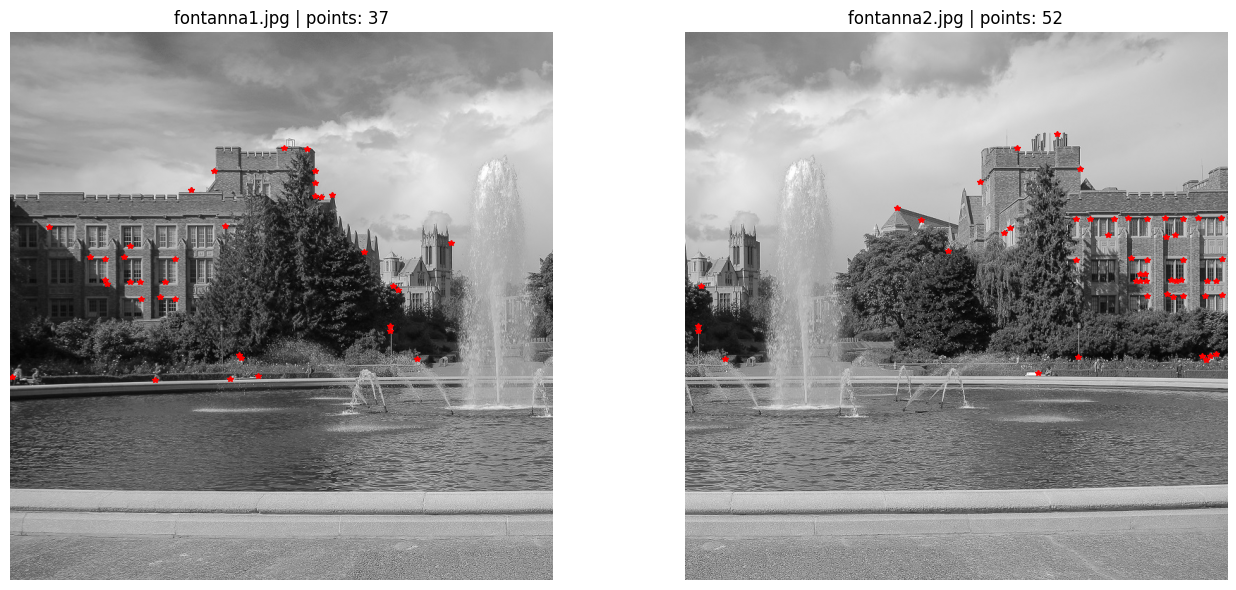

budynek1.jpg: 43 points
budynek2.jpg: 20 points


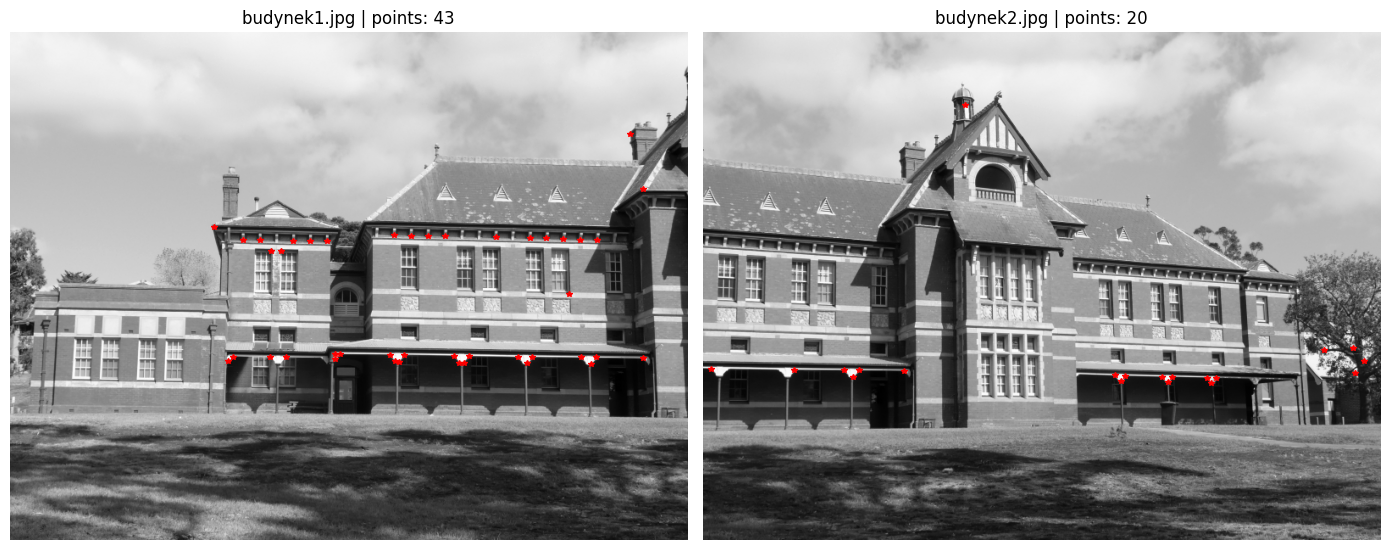

In [27]:
def process_pair(
    left_path: Path,
    right_path: Path,
    sobel_size: int = 7,
    gauss_size: int = 7,
    max_size: int = 7,
    threshold: float = 0.6,
) -> tuple[tuple[np.ndarray, np.ndarray], tuple[np.ndarray, np.ndarray]]:
    left = cv2.imread(str(left_path), cv2.IMREAD_GRAYSCALE)
    right = cv2.imread(str(right_path), cv2.IMREAD_GRAYSCALE)

    if left is None or right is None:
        raise FileNotFoundError(f"Cannot read one of images: {left_path}, {right_path}")

    h_left = harris_response(left, sobel_ksize=sobel_size, gauss_ksize=gauss_size)
    h_right = harris_response(right, sobel_ksize=sobel_size, gauss_ksize=gauss_size)

    pts_left = find_max(h_left, size=max_size, threshold=threshold)
    pts_right = find_max(h_right, size=max_size, threshold=threshold)

    print(f"{left_path.name}: {len(pts_left[0])} points")
    print(f"{right_path.name}: {len(pts_right[0])} points")

    draw_pair_with_stars(left, pts_left, left_path.name, right, pts_right, right_path.name)

    return pts_left, pts_right


# Works both when notebook is run from repo root or from inside lab06 directory
DATA_DIR = Path("lab06/data") if Path("lab06/data").exists() else Path("data")

fontanna_pts = process_pair(DATA_DIR / "fontanna1.jpg", DATA_DIR / "fontanna2.jpg")
budynek_pts = process_pair(DATA_DIR / "budynek1.jpg", DATA_DIR / "budynek2.jpg")


## Ćwiczenie 6.2 - prosta deskrypcja i dopasowanie

Implementacja zgodna z poleceniem:
- deskryptor = wycinek (patch) wokół punktu,
- odrzucenie punktów blisko krawędzi obrazu,
- dopasowanie brute-force (miara L1),
- zwrot i wizualizacja `N=20` najlepszych dopasowań.


In [28]:
def build_patch_descriptors(
    image_gray: np.ndarray,
    pts: tuple[np.ndarray, np.ndarray],
    size: int = 15,
    affine_norm: bool = False,
) -> list[tuple[tuple[int, int], np.ndarray]]:
    """Create descriptors as square patches around detected points."""
    y_max, x_max = image_gray.shape

    # As in instruction: keep only points where full neighborhood fits inside image.
    valid_pts = list(
        filter(
            lambda pt: pt[0] >= size and pt[0] < y_max - size and pt[1] >= size and pt[1] < x_max - size,
            zip(pts[0], pts[1]),
        )
    )

    descriptors: list[tuple[tuple[int, int], np.ndarray]] = []
    for y, x in valid_pts:
        patch = image_gray[y - size : y + size + 1, x - size : x + size + 1].astype(np.float32)

        if affine_norm:
            # w_aff = (w - mean(w)) / std(w), with safe fallback for std=0
            mean = float(np.mean(patch))
            std = float(np.std(patch))
            if std > 1e-12:
                patch = (patch - mean) / std
            else:
                patch = patch - mean

        descriptors.append(((int(y), int(x)), patch.reshape(-1)))

    return descriptors


def match_descriptors(
    desc1: list[tuple[tuple[int, int], np.ndarray]],
    desc2: list[tuple[tuple[int, int], np.ndarray]],
    n: int = 20,
) -> list[tuple[tuple[int, int], tuple[int, int], float]]:
    """Brute-force match: for each descriptor from list1 find best in list2 by L1 distance."""
    matches: list[tuple[tuple[int, int], tuple[int, int], float]] = []

    if not desc1 or not desc2:
        return matches

    for pt1, vec1 in desc1:
        best_dist = np.inf
        best_pt2 = None

        for pt2, vec2 in desc2:
            dist = float(np.sum(np.abs(vec1 - vec2)))
            if dist < best_dist:
                best_dist = dist
                best_pt2 = pt2

        if best_pt2 is not None:
            matches.append((pt1, best_pt2, best_dist))

    matches.sort(key=lambda m: m[2])
    return matches[:n]


def plot_matches_custom(
    im1: np.ndarray,
    im2: np.ndarray,
    matches: list[tuple[tuple[int, int], tuple[int, int], float]],
    title: str,
) -> None:
    rows1, cols1 = im1.shape
    rows2, cols2 = im2.shape

    if rows1 < rows2:
        im1 = np.concatenate((im1, np.zeros((rows2 - rows1, cols1), dtype=im1.dtype)), axis=0)
    elif rows2 < rows1:
        im2 = np.concatenate((im2, np.zeros((rows1 - rows2, cols2), dtype=im2.dtype)), axis=0)

    stacked = np.concatenate((im1, im2), axis=1)

    plt.figure(figsize=(14, 7))
    plt.imshow(stacked, cmap="gray")

    colors = ["r", "g", "b", "c", "m", "y"]
    for i, (pt1, pt2, _) in enumerate(matches):
        y1, x1 = pt1
        y2, x2 = pt2
        color = colors[i % len(colors)]
        plt.plot([x1, x2 + cols1], [y1, y2], color=color, linewidth=1.0)

    plt.title(title)
    plt.axis("off")
    plt.tight_layout()
    plt.show()


def run_ex62_pair(
    left_name: str,
    right_name: str,
    patch_size: int = 15,
    n_best: int = 20,
    threshold: float = 0.6,
    affine_norm: bool = False,
) -> list[tuple[tuple[int, int], tuple[int, int], float]]:
    left_path = DATA_DIR / left_name
    right_path = DATA_DIR / right_name

    im1 = cv2.imread(str(left_path), cv2.IMREAD_GRAYSCALE)
    im2 = cv2.imread(str(right_path), cv2.IMREAD_GRAYSCALE)
    if im1 is None or im2 is None:
        raise FileNotFoundError(f"Cannot read one of images: {left_path}, {right_path}")

    h1 = harris_response(im1, sobel_ksize=7, gauss_ksize=7, k=0.05)
    h2 = harris_response(im2, sobel_ksize=7, gauss_ksize=7, k=0.05)

    pts1 = find_max(h1, size=7, threshold=threshold)
    pts2 = find_max(h2, size=7, threshold=threshold)

    desc1 = build_patch_descriptors(im1, pts1, size=patch_size, affine_norm=affine_norm)
    desc2 = build_patch_descriptors(im2, pts2, size=patch_size, affine_norm=affine_norm)

    best = match_descriptors(desc1, desc2, n=n_best)

    print(f"Pair: {left_name} vs {right_name}")
    print(f"Detected points: {len(pts1[0])} vs {len(pts2[0])}")
    print(f"Descriptors kept: {len(desc1)} vs {len(desc2)}")
    print(f"Returned matches: {len(best)}\n")

    suffix = "(affine brightness normalization)" if affine_norm else "(raw patches)"
    plot_matches_custom(im1, im2, best, f"{left_name} vs {right_name} {suffix}")

    return best


Pair: fontanna1.jpg vs fontanna2.jpg
Detected points: 37 vs 52
Descriptors kept: 36 vs 49
Returned matches: 4



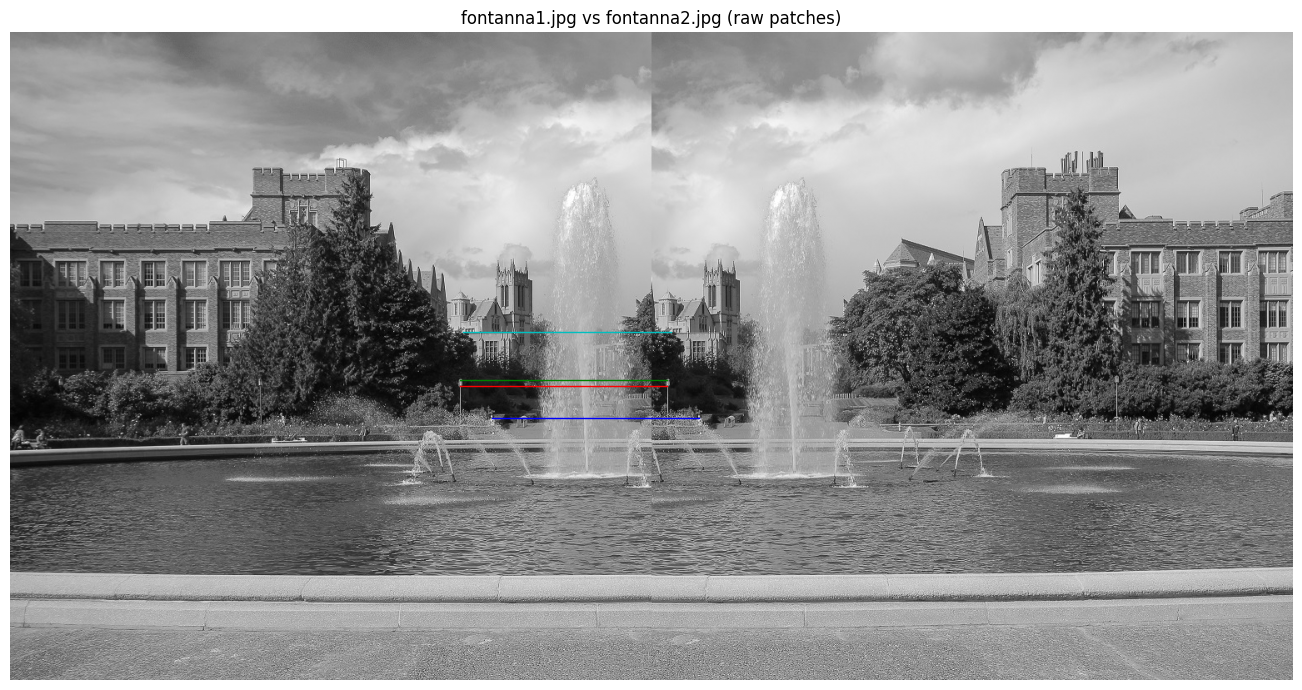

Pair: budynek1.jpg vs budynek2.jpg
Detected points: 43 vs 20
Descriptors kept: 43 vs 19
Returned matches: 20



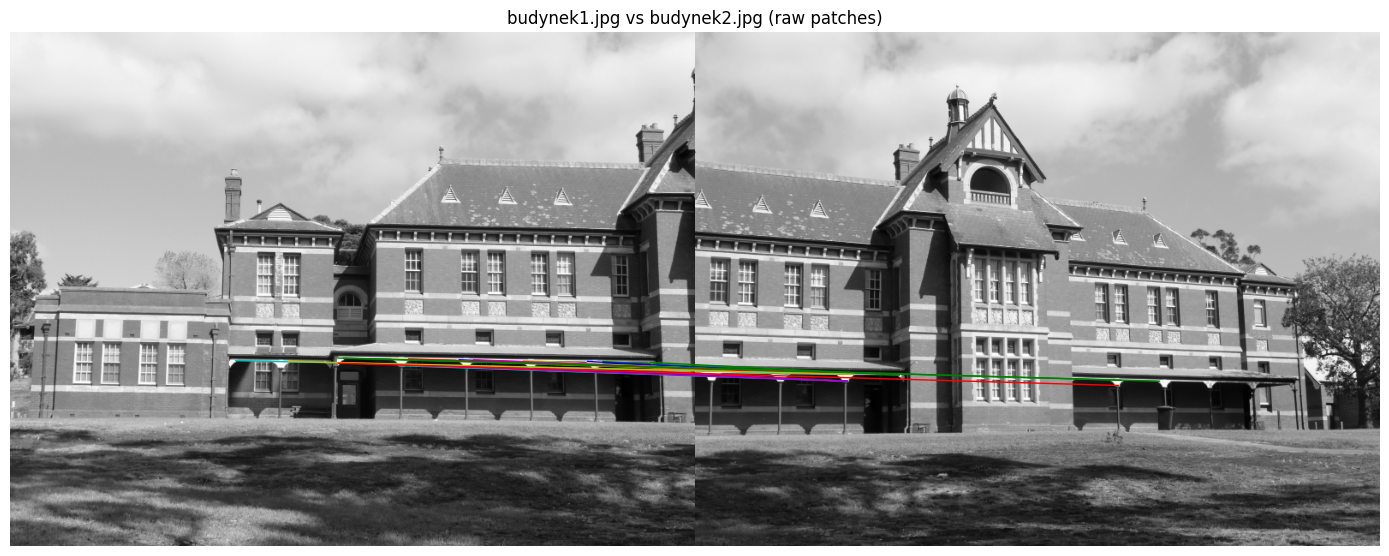

Pair: fontanna1.jpg vs fontanna_pow.jpg
Detected points: 37 vs 37
Descriptors kept: 36 vs 36
Returned matches: 4



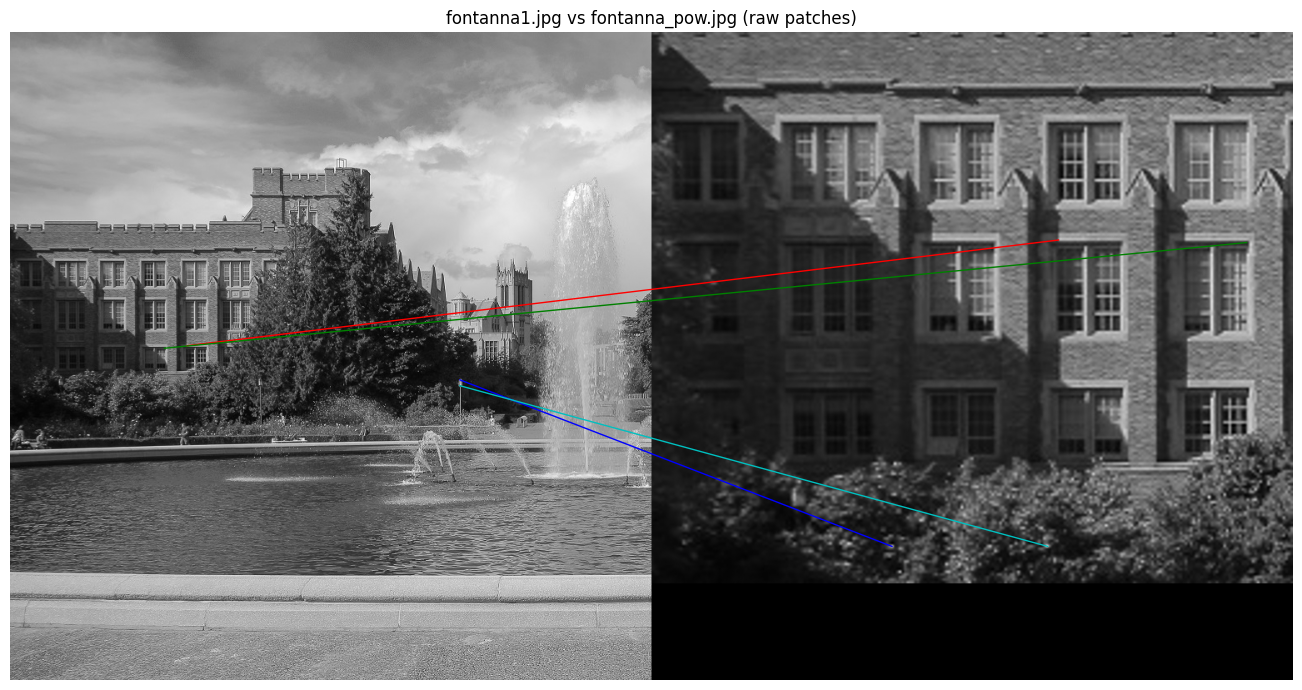

Pair: eiffel1.jpg vs eiffel2.jpg
Detected points: 28 vs 45
Descriptors kept: 28 vs 45
Returned matches: 5



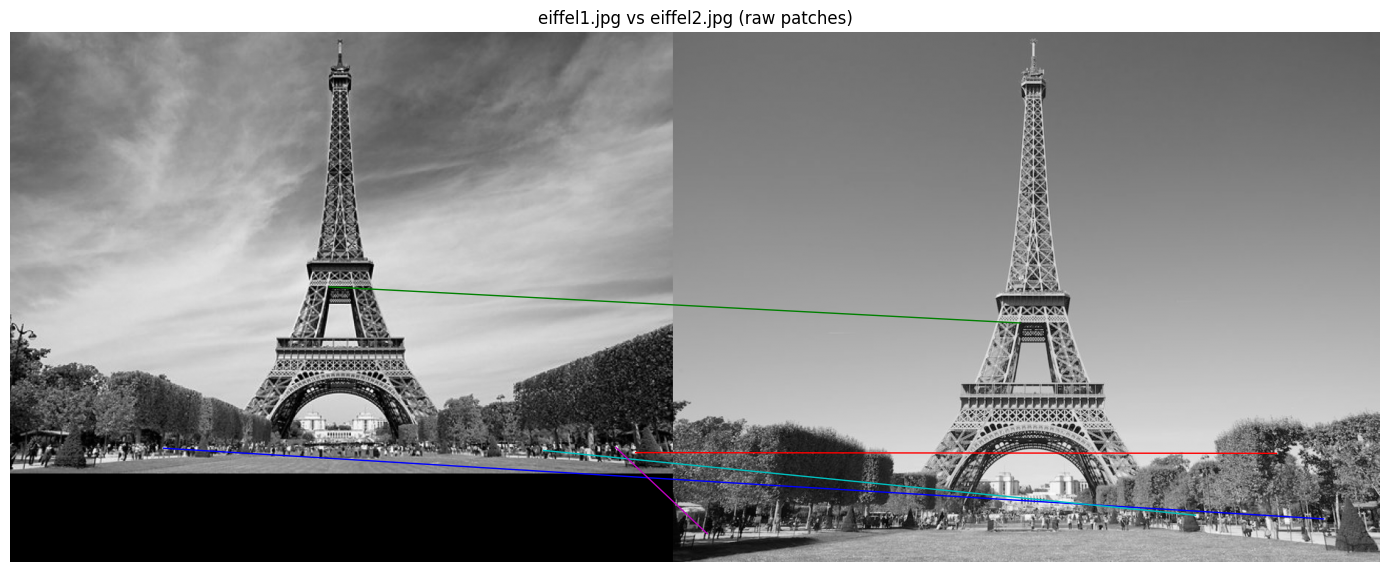

In [29]:
# Bazowa wersja deskryptora (surowe patche)
matches_fontanna = run_ex62_pair("fontanna1.jpg", "fontanna2.jpg", patch_size=15, n_best=4, threshold=0.6, affine_norm=False)
matches_budynek = run_ex62_pair("budynek1.jpg", "budynek2.jpg", patch_size=15, n_best=20, threshold=0.6, affine_norm=False)
matches_fontanna_scale = run_ex62_pair("fontanna1.jpg", "fontanna_pow.jpg", patch_size=15, n_best=4, threshold=0.6, affine_norm=False)
matches_eiffel = run_ex62_pair("eiffel1.jpg", "eiffel2.jpg", patch_size=15, n_best=5, threshold=0.6, affine_norm=False)


Pair: fontanna1.jpg vs fontanna2.jpg
Detected points: 37 vs 52
Descriptors kept: 36 vs 49
Returned matches: 4



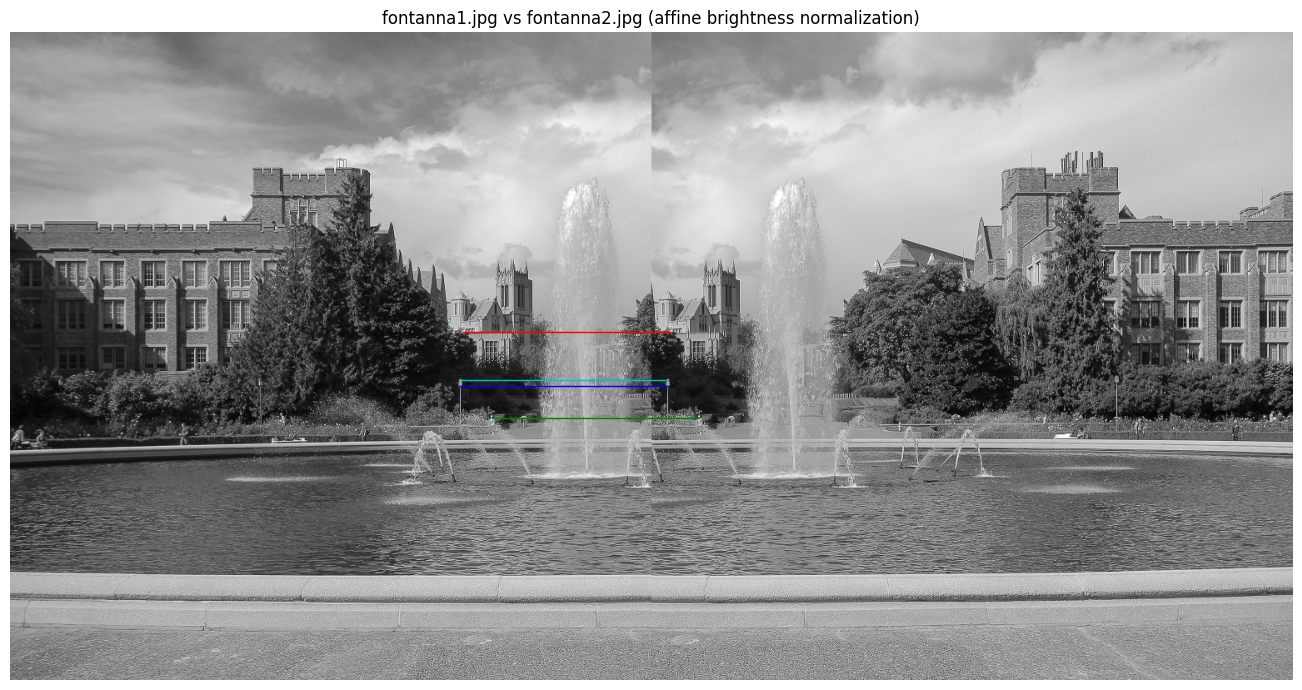

Pair: budynek1.jpg vs budynek2.jpg
Detected points: 43 vs 20
Descriptors kept: 43 vs 19
Returned matches: 10



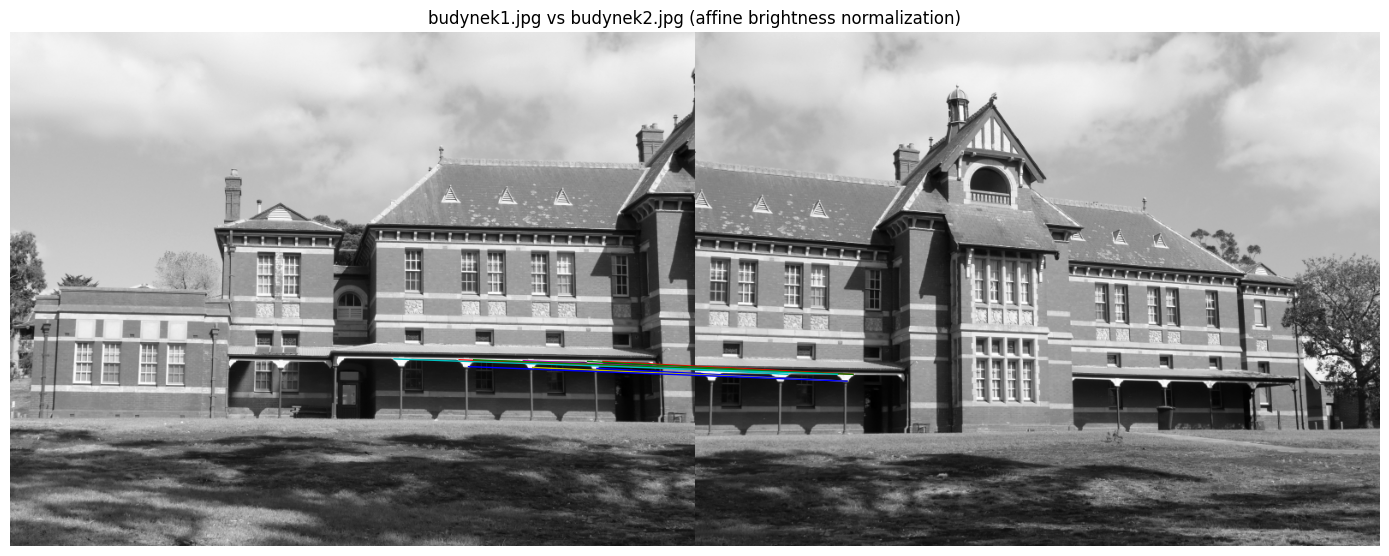

Pair: fontanna1.jpg vs fontanna_pow.jpg
Detected points: 37 vs 37
Descriptors kept: 36 vs 37
Returned matches: 6



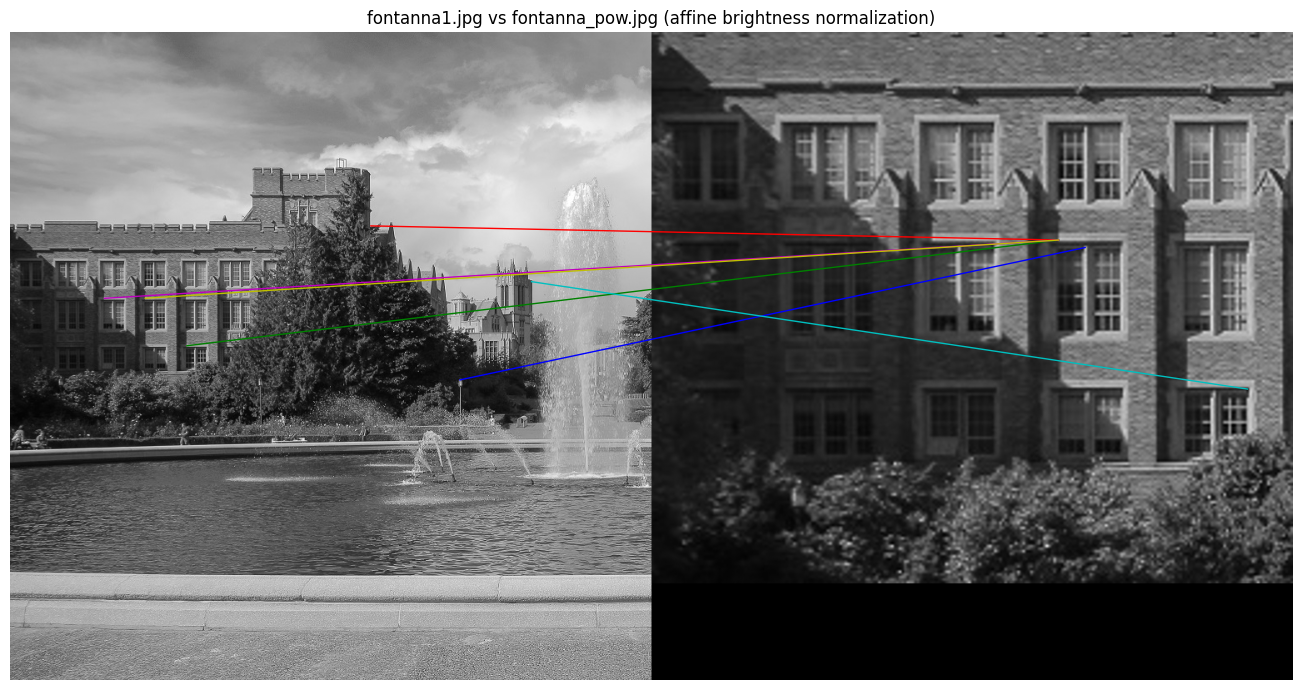

Pair: eiffel1.jpg vs eiffel2.jpg
Detected points: 28 vs 45
Descriptors kept: 28 vs 45
Returned matches: 5



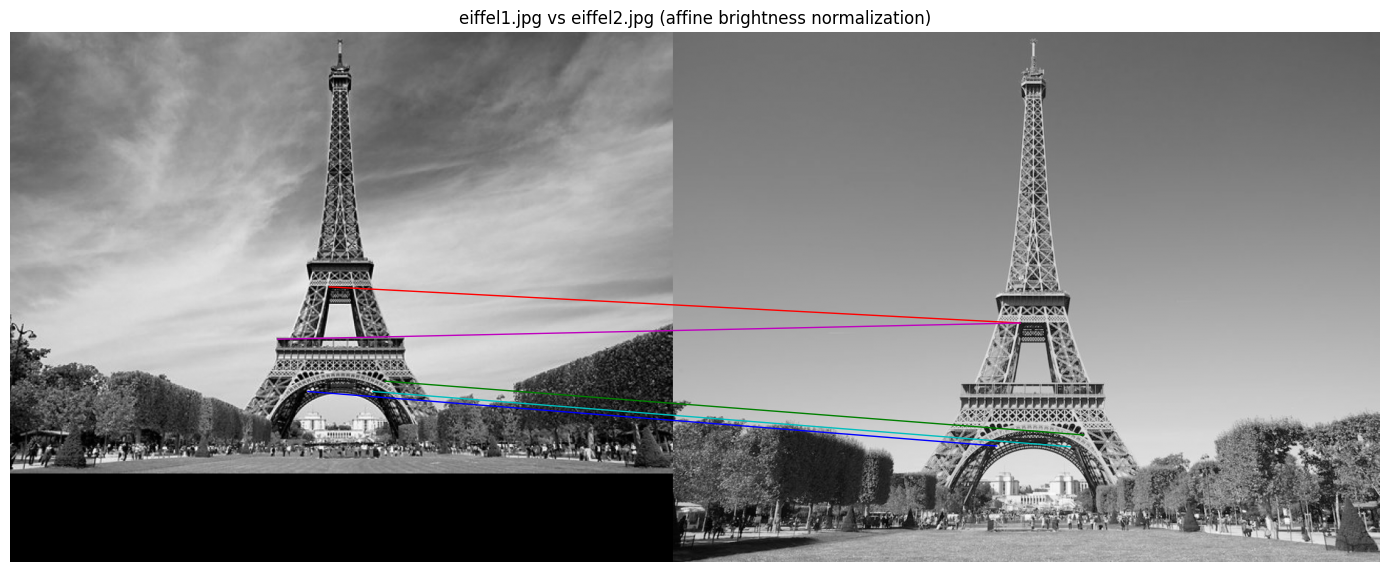

In [30]:
# Wersja z normalizacją afinicznych zmian jasności (wzór 6.9)
matches_fontanna_aff = run_ex62_pair("fontanna1.jpg", "fontanna2.jpg", patch_size=15, n_best=4, threshold=0.6, affine_norm=True)
matches_budynek_aff = run_ex62_pair("budynek1.jpg", "budynek2.jpg", patch_size=15, n_best=10, threshold=0.6, affine_norm=True)
matches_fontanna_scale_aff = run_ex62_pair("fontanna1.jpg", "fontanna_pow.jpg", patch_size=6, n_best=6, threshold=0.6, affine_norm=True)
matches_eiffel_aff = run_ex62_pair("eiffel1.jpg", "eiffel2.jpg", patch_size=15, n_best=5, threshold=0.6, affine_norm=True)


## Ćwiczenie 6.3 - uproszczony ORB (FAST + orientowany BRIEF)

Implementacja kroków z polecenia:
- FAST do detekcji punktów,
- miara Harrisa dla punktów FAST,
- filtracja NMS 3x3,
- odrzucenie punktów bez pełnego otoczenia 31x31,
- wybór N najlepszych punktów,
- orientacja z centroidu jasności,
- deskryptor BRIEF 256-bit z rotacją par punktów,
- dopasowanie brute-force metryką Hamminga.


In [31]:
def load_brief_pairs(path: Path) -> np.ndarray:
    pairs = np.loadtxt(path, dtype=np.float32)
    if pairs.shape != (256, 4):
        raise ValueError(f"Expected (256,4), got {pairs.shape}")
    return pairs


def harris_score_map(image_gray: np.ndarray) -> np.ndarray:
    # Raw Harris map (not normalized) used for ranking FAST points.
    image_f = image_gray.astype(np.float32)
    return cv2.cornerHarris(image_f, blockSize=2, ksize=3, k=0.05)


def fast_detect_with_harris(image_gray: np.ndarray, fast_threshold: int = 20) -> list[dict]:
    fast = cv2.FastFeatureDetector_create(threshold=fast_threshold, nonmaxSuppression=False)
    kps = fast.detect(image_gray, None)
    hmap = harris_score_map(image_gray)

    points = []
    h, w = image_gray.shape
    for kp in kps:
        x = int(round(kp.pt[0]))
        y = int(round(kp.pt[1]))
        if 0 <= x < w and 0 <= y < h:
            points.append({"x": x, "y": y, "harris": float(hmap[y, x])})
    return points


def nms_points_3x3(points: list[dict], image_shape: tuple[int, int]) -> list[dict]:
    h, w = image_shape
    score_map = np.full((h, w), -np.inf, dtype=np.float32)
    for p in points:
        y, x = p["y"], p["x"]
        if p["harris"] > score_map[y, x]:
            score_map[y, x] = p["harris"]

    local_max = cv2.dilate(score_map, np.ones((3, 3), dtype=np.uint8))
    selected = []
    seen = set()
    for p in points:
        y, x = p["y"], p["x"]
        if (y, x) in seen:
            continue
        if np.isfinite(score_map[y, x]) and score_map[y, x] == local_max[y, x]:
            selected.append(p)
            seen.add((y, x))
    return selected


def keep_full_patch(points: list[dict], image_shape: tuple[int, int], radius: int = 15) -> list[dict]:
    h, w = image_shape
    return [
        p
        for p in points
        if radius <= p["x"] < (w - radius) and radius <= p["y"] < (h - radius)
    ]


def compute_orientation_intensity_centroid(image_gray: np.ndarray, x: int, y: int, radius: int = 15) -> float:
    patch = image_gray[y - radius : y + radius + 1, x - radius : x + radius + 1].astype(np.float32)
    yy, xx = np.mgrid[-radius: radius + 1, -radius: radius + 1]
    m10 = float(np.sum(xx * patch))
    m01 = float(np.sum(yy * patch))
    angle = float(np.arctan2(m01, m10))
    return angle


def rotate_point(x: float, y: float, angle: float) -> tuple[int, int]:
    # Standard 2D rotation used to orient BRIEF pairs by keypoint angle.
    xr = np.cos(angle) * x - np.sin(angle) * y
    yr = np.sin(angle) * x + np.cos(angle) * y
    return int(round(xr)), int(round(yr))


def compute_brief_descriptor(image_gray: np.ndarray, x: int, y: int, angle: float, pairs: np.ndarray) -> np.ndarray:
    # Pre-blur required by instruction for BRIEF (5x5).
    blurred = cv2.GaussianBlur(image_gray, (5, 5), sigmaX=0)
    h, w = blurred.shape
    bits = np.zeros(256, dtype=np.uint8)

    for i, (x1, y1, x2, y2) in enumerate(pairs):
        rx1, ry1 = rotate_point(float(x1), float(y1), angle)
        rx2, ry2 = rotate_point(float(x2), float(y2), angle)

        px1, py1 = x + rx1, y + ry1
        px2, py2 = x + rx2, y + ry2

        if not (0 <= px1 < w and 0 <= py1 < h and 0 <= px2 < w and 0 <= py2 < h):
            bits[i] = 0
            continue

        bits[i] = 1 if blurred[py1, px1] < blurred[py2, px2] else 0

    return bits


def build_orb_like_features(
    image_gray: np.ndarray,
    pairs: np.ndarray,
    fast_threshold: int = 20,
    n_keep: int = 300,
) -> list[dict]:
    points = fast_detect_with_harris(image_gray, fast_threshold=fast_threshold)
    points = nms_points_3x3(points, image_gray.shape)
    points = keep_full_patch(points, image_gray.shape, radius=15)
    points = sorted(points, key=lambda p: p["harris"], reverse=True)[:n_keep]

    features = []
    for p in points:
        x, y = p["x"], p["y"]
        angle = compute_orientation_intensity_centroid(image_gray, x, y, radius=15)
        desc = compute_brief_descriptor(image_gray, x, y, angle, pairs)
        features.append({"pt": (y, x), "harris": p["harris"], "angle": angle, "desc": desc})

    return features


def hamming_distance(a: np.ndarray, b: np.ndarray) -> int:
    return int(np.count_nonzero(a ^ b))


def match_orb_like_features(
    f1: list[dict],
    f2: list[dict],
    n_matches: int = 40,
) -> list[tuple[tuple[int, int], tuple[int, int], int]]:
    matches = []
    if not f1 or not f2:
        return matches

    for a in f1:
        best_d = 10**9
        best_pt = None
        for b in f2:
            d = hamming_distance(a["desc"], b["desc"])
            if d < best_d:
                best_d = d
                best_pt = b["pt"]
        if best_pt is not None:
            matches.append((a["pt"], best_pt, best_d))

    matches.sort(key=lambda m: m[2])
    return matches[:n_matches]


def run_ex63_pair(
    left_name: str = "fontanna1.jpg",
    right_name: str = "fontanna2.jpg",
    n_keep: int = 300,
    n_matches: int = 40,
    fast_threshold: int = 20,
) -> tuple[list[dict], list[dict], list[tuple[tuple[int, int], tuple[int, int], int]]]:
    pairs = load_brief_pairs(DATA_DIR / "orb_descriptor_positions.txt")

    im1 = cv2.imread(str(DATA_DIR / left_name), cv2.IMREAD_GRAYSCALE)
    im2 = cv2.imread(str(DATA_DIR / right_name), cv2.IMREAD_GRAYSCALE)
    if im1 is None or im2 is None:
        raise FileNotFoundError(f"Cannot read {left_name} or {right_name}")

    f1 = build_orb_like_features(im1, pairs, fast_threshold=fast_threshold, n_keep=n_keep)
    f2 = build_orb_like_features(im2, pairs, fast_threshold=fast_threshold, n_keep=n_keep)
    matches = match_orb_like_features(f1, f2, n_matches=n_matches)

    print(f"Pair: {left_name} vs {right_name}")
    print(f"ORB-like features kept: {len(f1)} vs {len(f2)}")
    print(f"Best matches returned: {len(matches)}")

    plot_matches_custom(im1, im2, matches, f"EX6.3 ORB-like: {left_name} vs {right_name}")

    return f1, f2, matches


Pair: fontanna1.jpg vs fontanna2.jpg
ORB-like features kept: 300 vs 300
Best matches returned: 51


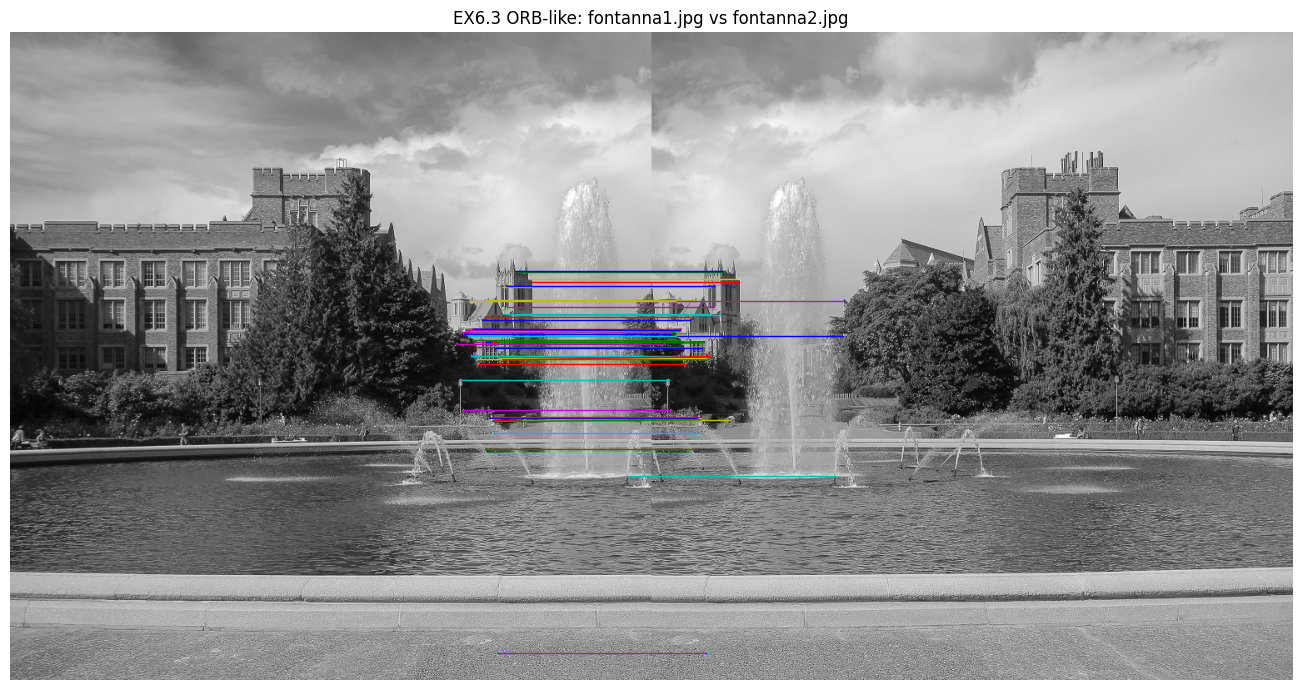

EX6.2 (Harris+patch) matches: 4
EX6.3 (ORB-like) matches: 51


In [38]:
# Ćwiczenie 6.3: para jak w 6.2 (fontanna)
orb_f1, orb_f2, orb_matches = run_ex63_pair("fontanna1.jpg", "fontanna2.jpg", n_keep=300, n_matches=51, fast_threshold=20)

# Proste porównanie liczby dopasowań z 6.2 (jeśli cell 6.2 była wykonana):
if "matches_fontanna" in globals():
    print(f"EX6.2 (Harris+patch) matches: {len(matches_fontanna)}")
print(f"EX6.3 (ORB-like) matches: {len(orb_matches)}")
